---
title: "Trotterized Hubbard Model"
title-block-banner: true
<!--abstract: |-->
header-includes: |
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
    <link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:ital,opsz,wght@0,8..60,200..900;1,8..60,200..900&display=swap" rel="stylesheet">
link-citations: yes
mainfont: "Source Serif 4"
fontsize: 18
font-weight: 400
comments:
  giscus:
    repo: minhtriet/hubbard
---

::: {.callout-tip}

## Summary
Generic resource estimation overestimates Trotter cost for structured Hamiltonians like Hubbard. Tighter-bound method optimize for every quantum states in Hilbert space, while only a handful of states are relevant for material science tasks. Moreover, the bound calculation could not suggest the parameters for Trotter simulation.

We show this empirically using spectral norm, commutator bounds, and state-specific fidelity on a 2×2 model. We then demonstrate that Hubbard's structure, and focusing on physics relevant states can be exploited to produce a tighter bound and derive the parameters for Trotterization to achieve such error bound.

- In @sec-naive-bound, we use naive methods to prove the consistent cost takes time to estimate, but also overestimate for the physical relevant states
- In @sec-physics-bound, we prove that the cost of gate and number of steps is smaller for a relevant physics state.
- In @sec-analytic (done as the next step), we provide analytical solution for state-specific error bound estimataion

:::


In [1]:
# | code-fold: true
# | code-summary: "Import libraries"
import logging
from collections import defaultdict
from scipy import sparse
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qp
import pennylane.estimator as qre
from pennylane.resource import SpectralNormError
import time as pytime
from tqdm import tqdm

logging.basicConfig(level=logging.INFO)

# Setup {#sec-setup}

In [2]:
t = 1.0
U = 4.0
time = 3  # The time of evolution (t in exp(-iHt))

# number of Trotter steps, proposally not good to show the power of higher Trotter order
n_steps = int(time * 4)
num_steps = [10, 20, 40, 80, 120]

n_cells = [2, 2, 1]
orders = [1, 2, 4]
H = qp.spin.fermi_hubbard(
    lattice="cubic",
    n_cells=n_cells,
    hopping=t,
    coulomb=U,
    boundary_condition=False,
    mapping="jordan_wigner",
)
n_qubits = H.num_wires

I create a $2 \times 2$ lattice, with 4 sites, and 8 qubits. The notion is

| Qubit | Spin orbital |
|-------|--------------|
| 0     | site 0 ↑     |
| 1     | site 0 ↓     |
| 2     | site 1 ↑     |
| 3     | site 1 ↓     |
| 4     | site 2 ↑     |
| 5     | site 2 ↓     |
| 6     | site 3 ↑     |
| 7     | site 3 ↓     |

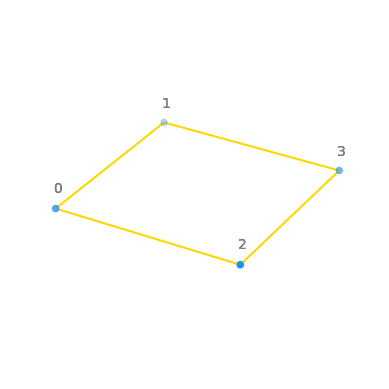

In [12]:
# | code-fold: true
# | code-summary: "Import libraries"
def plot_lattice(lattice, figsize=None, showlabel=True):

    nodes = lattice.lattice_points
    fig = plt.figure()
    
    ax = fig.add_subplot(111, projection='3d')

    for edge in lattice.edges:
        start_index, end_index, color = edge
        start_pos, end_pos = nodes[start_index], nodes[end_index]

        x_axis = [start_pos[0], end_pos[0]]
        y_axis = [start_pos[1], end_pos[1]]
        z_axis = [start_pos[2], end_pos[2]]
        ax.plot(x_axis, y_axis, z_axis, color='gold')        

        if showlabel:
            for index, pos in enumerate(nodes):
                ax.text(pos[0]-0.02, pos[1]+0.01, pos[2]+0.01, str(index), color='gray')
    ax.scatter(nodes[:,0], nodes[:,1], nodes[:,2], color='dodgerblue')                
    
    ax.axis("off")
    plt.show()

lattice = qp.spin.generate_lattice('cubic', n_cells)
plot_lattice(lattice)

# Naive Trotter error bound {#sec-naive-bound}

::: {.callout-tip}

## Summary
How badly do standard Trotter error bounds overestimate cost for specific observables in Hubbard, and what's the practical implication for resource estimates?"
The spectral norm $\lVert {U_{exact} - U_{trotter}}\rVert_2$ measures the maximum possible deviation over all possible input states in the entire Hilbert space.

However in common application, these relevant states (e.g, low-energy excited states with specific symmetries) is in a much smaller space. Therefore it is not the best interest to tune the Trotter using the Spectral Norm.

:::

<!-- This link is interesting https://fermi-hubbard-commutators.readthedocs.io/en/latest/commutator_bounds.html


Compute grouping here  https://docs.pennylane.ai/en/stable/code/api/pennylane.ops.op_math.LinearCombination.html#pennylane.ops.op_math.LinearCombination.compute_grouping
-->

## Spectral Norm {#sec-sec-spectral-norm}

The first method calculate the biggest single value of $\lVert {U_{exact} - U_{trotter}}\rVert_2$.  With our small system, the Hamiltonian matrix is tractable and diagonalizable. However, it stuggles at 16 qubits, which would result in $2^{16} \times 2^{16}$ matrix. Due to the locality nature of Hubbard model, sparse matrix could save a lot of memory, but not every operator has a sparse matrix representation in Pennylane as of 2026.

<!--
```
exact_op = qp.exp(H, -1j * time)
sparse_mat_exact_op = exact_op.sparse_matrix()
spectral_error = {}

for order in tqdm.tqdm(orders):
    approx_op = qp.TrotterProduct(-H, n=n_steps, time=time, order=order)
    sparse_mat_approx_op = sparse.csr_matrix(qp.matrix(approx_op))
    spectral_error[order] =  sparse.linalg.svds(sparse_mat_exact_op - sparse_mat_approx_op, k=1, which='LM', return_singular_vectors=False)[0]

print(
    "\n".join(
        [f"Order: {k}, Spectral error: {v:5f}" for k, v in spectral_error.items()]
    )
)```
-->

In [3]:
exact_op = qp.exp(H, -1j * time)
spectral_error = {}
 
for order in tqdm(orders):
    approx_op = qp.TrotterProduct(-H, n=num_steps[0], time=time, order=order)
    error = SpectralNormError.get_error(exact_op, approx_op)
    spectral_error[order] = error

100%|██████████| 3/3 [00:42<00:00, 14.13s/it]


A higher Trotter order guarantees better spectral norm errors but also requires more non-Clifford gates. I visualize this at @fig-gate-order.

## Commutator aware method

Calculating spectral norm is memory expensive because it requires diagonalizing the operators. This method promises better memory scalability, but the estimation time cost is grows exponentially with order

In [4]:
for order in orders[:2]:
    op = qp.TrotterProduct(-H, n=num_steps[0], time=time, order=order)
    start = pytime.time()
    one_norm_error_bound = op.error(method="one-norm-bound")
    commutator_error_bound = op.error(method="commutator-bound")
    print(f"Order {order}, Calculation time: {pytime.time() - start}")
    print(f"  - One-norm bound: {one_norm_error_bound}")
    print(f"  - Commutator bound: {commutator_error_bound}")
    print()

Order 1, Calculation time: 1.371994972229004
  - One-norm bound: SpectralNormError(518.4)
  - Commutator bound: SpectralNormError(129.6)

Order 2, Calculation time: 154.1182496547699
  - One-norm bound: SpectralNormError(5598.72)
  - Commutator bound: SpectralNormError(357.12)



Even for this small lattice instance, evaluating the available Trotter error bounds is computationally expensive. More importantly, the resulting estimates provide limited practical guidance for selecting Trotterization parameters. The different error estimation methods can also yield inconsistent conclusions, making it difficult to extract actionable insights for simulation design. We find a way gleam useful information for Trotterization in the next step.

For an explanation of the contradictions of the methods as well as the time cost, I invite readers to session @sec-sec-a1

From a physical perspective, the worst-case error over the entire Hilbert space is often of limited relevance. Quantum many-body systems typically explore only a small, physically meaningful manifold of states, while large portions of the Hilbert space remain inaccessible under realistic dynamics. Therefore, we propose a state-aware error estimation framework that evaluates Trotter errors with respect to physically relevant states rather than the full Hilbert space.

# Physics state-awared error bound estimation {#sec-physics-bound}

::: {.callout-tip}

## Summary
This section shows an example of that leveraging state fidelity gives a tighter and more relevant bound for Trotterization. We would develop the math in the next section

:::

The next natural question is for the Hubbard model, what the most relavant states are? In this example we use half-filled Neel state ($\ket{0101...01}$), which is standard for studying Mott insulators.

A commonly used state called Haar-random states are relevant for complexity proofs due to its uniformly distribution across the full Hilbert space, making them worst-case inputs. However, they have no physical relevance to Hubbard physics.

## State initialization

Neel state ($\ket{0110...01}$) is the standard state for studying ferromagnetics problem. Here is the code to prepare for the state, conforming to the notation used in @sec-setup

In [5]:
def prepare_neel_state(wires):
    """Néel state: alternating up/down on bipartite lattice"""
    for site in range(wires // 2):
        if site % 2 == 0:
            qp.PauliX(wires=2 * site)
        else:
            qp.PauliX(wires=2 * site + 1)

## Simulation

In [6]:
# | code-fold: true
# | code-summary: "Define the exact and the Trotterization circuit"

dev = qp.device("default.qubit")


@qp.qnode(dev)
def exact_circ(H, t, wires):
    """
    Simluate exact evolution
    """
    prepare_neel_state(wires)
    qp.exp(H, -1j * t)
    return qp.state()


@qp.qnode(dev)
def trotter_circ(H, num_steps, t, wires, order=1):
    """
    Because TrotterProduct evaluate exp(iHt), not exp(-iHt), we
    flip the H
    """
    prepare_neel_state(wires)
    qp.TrotterProduct(-H, n=num_steps, time=t, order=order)
    return qp.state()

In [7]:
resource_est = {}
for order in orders:
    resources_exec = qre.estimate(trotter_circ)(H, n_steps, time, n_qubits, order=order)
    resource_est[order] = resources_exec.gate_counts

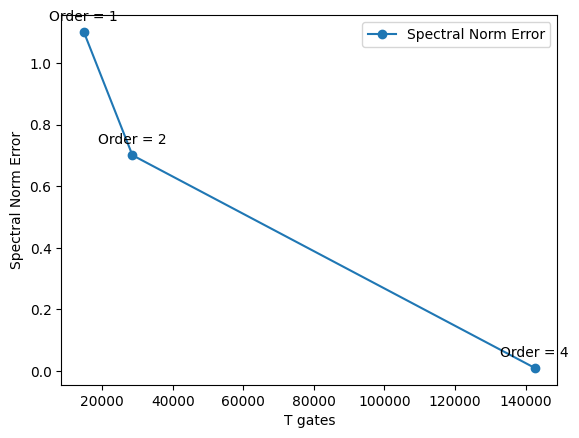

In [8]:
# | label: fig-gate-order
# | fig-cap: "The relation between Spectral Norm Error, Trotter Order and the number of $T$ gates required for the Trotter circuit"
error_array = [spectral_error[order] for order in orders]
gates = [resource_est[order]["T"] for order in orders]

plt.plot(gates, error_array, label="Spectral Norm Error", marker="o")
for o, xi, yi in zip(orders, gates, error_array):
    plt.annotate(
        f"Order = {o}",
        (xi, yi),
        textcoords="offset points",
        xytext=(0, 8),  # offset label above point
        ha='center'
    )

plt.ylabel("Spectral Norm Error")
plt.xlabel("T gates")
plt.legend()
plt.show()

So we need to have `{python} gates[2]` T gates to make a simulation for `{python} time` seconds on a modest-sized Hubbard simulation.

In [9]:
exact_state = exact_circ(H, time, n_qubits)
error_dicts = {}
state_fidelities = defaultdict(dict)

for order in orders:
    for n_step in num_steps:
        trotter_state = trotter_circ(H, n_step, time, n_qubits, order=order)
        state_fidelities[order][n_step] = qp.math.fidelity_statevector(exact_state, trotter_state)

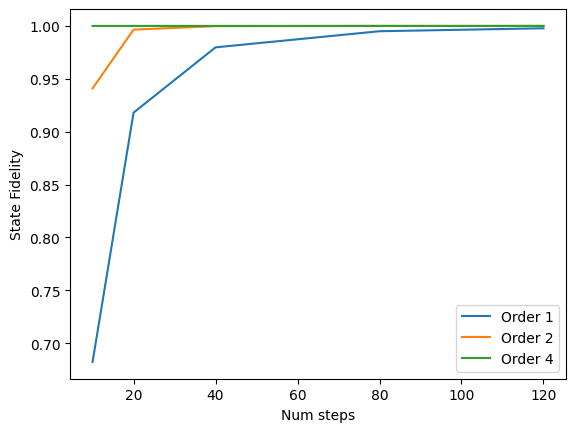

In [10]:
state_fidelity_order_1_array = [state_fidelities[orders[0]][step] for step in num_steps]
state_fidelity_order_2_array = [state_fidelities[orders[1]][step] for step in num_steps]
state_fidelity_order_4_array = [state_fidelities[orders[2]][step] for step in num_steps]

plt.plot(num_steps, state_fidelity_order_1_array, label="Order 1")
plt.plot(num_steps, state_fidelity_order_2_array, label="Order 2")
plt.plot(num_steps, state_fidelity_order_4_array, label="Order 4")

plt.ylabel("State Fidelity")
plt.xlabel("Num steps")
plt.legend()
plt.show()

With higher orders, number of steps matter less. But the increment of the number of T gates are fast (See @fig-gate-order)

# (Next step) (Draft) Analtical error bound for a class of states {#sec-analytic}

::: {.callout-tip}

## Summary
- Can we assume that the best Trotter physical sensible state can make it work for every thing in smaller manifold
- Is it more meaningful than normal bound
- The end goal is that we don't have to simulate to get the estimation
:::

## Hubbard Hamiltonian properties

We have two types of interaction in Hubbard: Hopping $T$ and on-site repulsion $U$, explore the math here

## State specific properties
Do physically relevant states seems to reduce the practical advantage of higher-order 

# (Next step) Recommendations for physicsists

<!--
If we increase the order based on the Spectral norm estimation, then the number of gates vs accuracy looks like this

But if we increase the order based on the state fidelity, then the number of gates vs accuracy looks like this
-->

<!--
# Goal
- Practical resource estimation for early-to-intermediate fault-tolerant quantum simulation of strongly correlated materials. Choose 3D Hubbard model using PennyLane's Labs estimator
- Give systematic, empirical comparison of worst-case vs. observable-specific Trotter error bounds
- Able to distinguish asymptotic theory from realistic hardware constraints;
- Capable of producing technically honest estimates that are useful for strategic decision-making inside an FTQC organization.
-->

## (Next step) QSVT with QROM vs Trotterization

<!--
QSVT/QROM is especially powerful when the Hamiltonian is given as a large irregular table: But the Hubbard model on a regular lattice is not an arbitrary table. It has simple repeated structure:

- nearest-neighbor hopping,
- osite interaction,
- mostly uniform coefficients,
- sparse local geometry.
-->

# Appendix

## Appendix 1 {#sec-sec-a1}
<!--
This seems counter intuitive when commutator bound is more pessimistic than one-norm bound, and none of them are close to the spectral norm. higher order's error should scale with $O(\frac{t}{n})$. Order 2 is better algorithmically but has worse worst-case combinatorial bound.

One-norm bound is faster because it just adds every possible error

Commutator bound is tighter here it finds every pair $i, j$ such that [Hᵢ, Hⱼ] = 0. For the Hubbard model, all the interaction terms V = Σ U nᵢ↑nᵢ↓ commute with each other, so this pruning is substantial.
Why it runs out of memory at high orders — the combinatorial explosion:
For an order-p Trotter formula, the commutator bound requires computing nested commutators to depth p+1. With N Hamiltonian terms:
Trotter orderCommutator depth needed# evaluations1depth 2~N²2depth 3~N³4depth 5~N⁵-->


Hi Danial. I finished the first draft of the page. To save your time, there is summary box at the start of every section. It should help you skim the section faster

If you have a hypothes.is account please let me know so that I can enable a better commenting method

The link is https://minhtriet.github.io/hubbard/